# 04 - Analise exploratoria dos dados interim

Esta segunda analise olha para os dados em `data/interim`, antes do preprocessamento usado para modelagem. O objetivo e entender a base como ela chega ao projeto: qualidade, descricoes de produtos, NCM, relacao entre descricao e NCM, e contexto da compra.

A analise separa as linhas de item usando a presenca da coluna de descricao do produto/servico. Isso e importante porque os arquivos interim tambem podem conter linhas com metadados da nota fiscal, nas quais as colunas de item ficam vazias.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
ITEMS_DIR = INTERIM_DIR / "items-notas-fiscais"
UNIQUE_ITEMS_PATH = INTERIM_DIR / "items-unicos" / "produtos-unicos-202501-202504.csv"

parquet_paths = sorted(ITEMS_DIR.glob("*.parquet"))
parquet_paths

[WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais/2025-01.parquet'),
 WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais/2025-02.parquet'),
 WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais/2025-03.parquet'),
 WindowsPath('c:/Users/samue/Scripts/Nofis-Classifier/data/interim/items-notas-fiscais/2025-04.parquet')]

In [2]:
def find_col(columns, *patterns):
    """Return the first column whose uppercase name contains all informed patterns."""
    normalized = {col: str(col).upper() for col in columns}
    for col, upper in normalized.items():
        if all(pattern.upper() in upper for pattern in patterns):
            return col
    raise KeyError(f"Nenhuma coluna encontrada para os padroes: {patterns}")


def optional_col(columns, *patterns):
    """Return a matching column or None when the source file does not provide it."""
    try:
        return find_col(columns, *patterns)
    except KeyError:
        return None


def to_number_br(series):
    """Convert Brazilian numeric strings such as '1.234,56' to float."""
    return pd.to_numeric(
        series.astype("string")
        .str.strip()
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce",
    )


def pct(series):
    """Format a ratio as percentage."""
    return (100 * series).round(2)

## Carregamento

Os arquivos mensais em Parquet sao combinados em um unico `DataFrame`. A coluna `mes_arquivo` e derivada do nome do arquivo para permitir comparacoes temporais simples.

In [3]:
if not parquet_paths:
    raise FileNotFoundError(f"Nenhum Parquet encontrado em {ITEMS_DIR}")

frames = []
for path in parquet_paths:
    month_df = pd.read_parquet(path)
    month_df["mes_arquivo"] = path.stem
    frames.append(month_df)

df = pd.concat(frames, ignore_index=True)
df.shape

(2237538, 40)

In [4]:
desc_col = find_col(df.columns, "PRODUTO/SERV")
ncm_col = find_col([col for col in df.columns if "TIPO" not in str(col).upper()], "NCM/SH")
ncm_tipo_col = optional_col(df.columns, "NCM/SH", "TIPO")
emitente_col = optional_col(df.columns, "SOCIAL", "EMITENTE")
cnpj_emitente_col = optional_col(df.columns, "CPF/CNPJ", "EMITENTE")
uf_col = optional_col(df.columns, "UF", "EMITENTE")
municipio_col = optional_col(df.columns, "MUNIC", "EMITENTE")
unidade_col = optional_col(df.columns, "UNIDADE")
quantidade_col = optional_col(df.columns, "QUANTIDADE")
valor_unitario_col = optional_col(df.columns, "VALOR", "UNIT")
valor_total_col = optional_col(df.columns, "VALOR", "TOTAL")
valor_nota_col = optional_col(df.columns, "VALOR", "NOTA")
chave_col = optional_col(df.columns, "CHAVE")

cols = {
    "descricao": desc_col,
    "ncm": ncm_col,
    "ncm_tipo": ncm_tipo_col,
    "emitente": emitente_col,
    "cnpj_emitente": cnpj_emitente_col,
    "uf_emitente": uf_col,
    "municipio_emitente": municipio_col,
    "unidade": unidade_col,
    "quantidade": quantidade_col,
    "valor_unitario": valor_unitario_col,
    "valor_total": valor_total_col,
    "valor_nota": valor_nota_col,
    "chave_acesso": chave_col,
}
pd.Series(cols, name="coluna_detectada")

descricao             DESCRIÇÃO DO PRODUTO/SERVIÇO
ncm                                  CÓDIGO NCM/SH
ncm_tipo                  NCM/SH (TIPO DE PRODUTO)
emitente                     RAZÃO SOCIAL EMITENTE
cnpj_emitente                    CPF/CNPJ Emitente
uf_emitente                            UF EMITENTE
municipio_emitente              MUNICÍPIO EMITENTE
unidade                                    UNIDADE
quantidade                              QUANTIDADE
valor_unitario                      VALOR UNITÁRIO
valor_total                            VALOR TOTAL
valor_nota                       VALOR NOTA FISCAL
chave_acesso                       CHAVE DE ACESSO
Name: coluna_detectada, dtype: str

In [5]:
items = df[df[desc_col].notna()].copy()
items["descricao_limpa_minima"] = items[desc_col].astype("string").str.strip().str.lower()
items["ncm_str"] = items[ncm_col].astype("string").str.replace(r"\.0$", "", regex=True).str.zfill(8)
items.loc[items[ncm_col].isna(), "ncm_str"] = pd.NA

if quantidade_col:
    items["quantidade_num"] = to_number_br(items[quantidade_col])
if valor_unitario_col:
    items["valor_unitario_num"] = to_number_br(items[valor_unitario_col])
if valor_total_col:
    items["valor_total_num"] = to_number_br(items[valor_total_col])
if valor_nota_col:
    items["valor_nota_num"] = to_number_br(items[valor_nota_col])

items.shape

(1765015, 46)

In [6]:
MAX_EXAMPLE_ROWS = 200_000
MAX_RELATION_ROWS = 75_000
items_for_examples = items.sample(n=min(len(items), MAX_EXAMPLE_ROWS), random_state=42) if len(items) else items
items_for_relation = items.sample(n=min(len(items), MAX_RELATION_ROWS), random_state=7) if len(items) else items
items_for_examples.shape

(200000, 46)

## 1. Qualidade da base

**Por que importa para o TCC:** identifica problemas antes do processamento, como ausencia de campos relevantes, duplicatas e diferencas entre meses.

In [7]:
resumo_geral = pd.DataFrame(
    {
        "metrica": [
            "linhas totais",
            "colunas",
            "linhas de item com descricao",
            "percentual de linhas de item",
            "duplicatas exatas no dataframe completo",
            "duplicatas exatas entre itens",
        ],
        "valor": [
            len(df),
            df.shape[1],
            len(items),
            f"{len(items) / len(df):.2%}",
            int(df.duplicated().sum()),
            int(items.duplicated().sum()),
        ],
    }
)
resumo_geral

,metrica,valor
0,linhas totais,2237538
1,colunas,40
2,linhas de item com descricao,1765015
3,percentual de linhas de item,78.88%
4,duplicatas exatas no dataframe completo,0
5,duplicatas exatas entre itens,0


In [8]:
linhas_por_mes = (
    df.groupby("mes_arquivo")
    .agg(
        linhas=(desc_col, "size"),
        linhas_item=(desc_col, lambda s: int(s.notna().sum())),
        descricoes_unicas=(desc_col, "nunique"),
        ncms_unicos=(ncm_col, "nunique"),
    )
    .assign(percentual_item=lambda d: pct(d["linhas_item"] / d["linhas"]))
)
linhas_por_mes

,linhas,linhas_item,descricoes_unicas,ncms_unicos,percentual_item
mes_arquivo,,,,,
2025-01,478562,369683,151290,4991,77.25
2025-02,608847,490657,168994,5055,80.59
2025-03,551362,434549,157845,4950,78.81
2025-04,598767,470126,171244,5023,78.52


In [9]:
tipos_e_ausentes = pd.DataFrame(
    {
        "coluna": df.columns,
        "tipo": [str(dtype) for dtype in df.dtypes],
        "ausentes_total": df.isna().sum().to_numpy(),
        "ausentes_total_pct": pct(df.isna().mean()).to_numpy(),
        "ausentes_itens_pct": pct(items.reindex(columns=df.columns).isna().mean()).to_numpy(),
    }
).sort_values("ausentes_itens_pct", ascending=False)
tipos_e_ausentes

,coluna,tipo,ausentes_total,ausentes_total_pct,ausentes_itens_pct
6,EVENTO MAIS RECENTE,str,1765015,78.88,100.00
7,DATA/HORA EVENTO MAIS RECENTE,str,1765015,78.88,100.00
27,DATA/HORA EVENTO,object,2237538,100.00,100.00
24,VALOR NOTA FISCAL,str,1765015,78.88,100.00
29,MOTIVO EVENTO,object,2237538,100.00,100.00
26,EVENTO,object,2237538,100.00,100.00
28,DESCRIÇÃO EVENTO,object,2237538,100.00,100.00
33,NCM/SH (TIPO DE PRODUTO),str,564992,25.25,5.24
36,UNIDADE,str,474248,21.20,0.10
5,DATA EMISSÃO,str,0,0.00,0.00


In [10]:
subset_duplicatas = [col for col in [desc_col, ncm_col, unidade_col, valor_total_col] if col]
duplicatas_por_chave = (
    items.groupby(subset_duplicatas, dropna=False)
    .size()
    .reset_index(name="ocorrencias")
    .sort_values("ocorrencias", ascending=False)
    .head(20)
)
duplicatas_por_chave

,DESCRIÇÃO DO PRODUTO/SERVIÇO,CÓDIGO NCM/SH,UNIDADE,VALOR TOTAL,ocorrencias
804950,PERSONALIZACAO NOVO PASSAPORTE BRASILEIRO PACOM DPF 32 PAG.,49119900.0,MI,"0,00",5622
804954,PERSONALIZACAO NOVO PASSAPORTE BRASILEIRO PACOM DPF 32 PAG.,49119900.0,MI,"1608,50",1817
804964,PERSONALIZACAO NOVO PASSAPORTE BRASILEIRO PACOM DPF 32 PAG.,49119900.0,MI,"4825,50",1081
804952,PERSONALIZACAO NOVO PASSAPORTE BRASILEIRO PACOM DPF 32 PAG.,49119900.0,MI,"12868,00",1003
804965,PERSONALIZACAO NOVO PASSAPORTE BRASILEIRO PACOM DPF 32 PAG.,49119900.0,MI,"6434,00",982
804953,PERSONALIZACAO NOVO PASSAPORTE BRASILEIRO PACOM DPF 32 PAG.,49119900.0,MI,"14476,50",940
804963,PERSONALIZACAO NOVO PASSAPORTE BRASILEIRO PACOM DPF 32 PAG.,49119900.0,MI,"32170,00",937
804962,PERSONALIZACAO NOVO PASSAPORTE BRASILEIRO PACOM DPF 32 PAG.,49119900.0,MI,"3217,00",906
804951,PERSONALIZACAO NOVO PASSAPORTE BRASILEIRO PACOM DPF 32 PAG.,49119900.0,MI,"11259,50",761
539187,INFUSOMAT COMPACT 100 240V,90189010.0,PEÇA,"100,00",694


## 2. Descricoes dos produtos

**Por que importa para o TCC:** caracteriza o problema de classificacao sobre textos curtos, ruidosos, abreviados e com padroes variados.

In [11]:
desc = items[desc_col].astype("string").str.strip()
desc_stats = pd.DataFrame(
    {
        "metrica": [
            "descricoes preenchidas",
            "descricoes unicas",
            "taxa de repeticao",
            "media de caracteres",
            "mediana de caracteres",
            "media de palavras",
            "mediana de palavras",
            "com numeros (%)",
            "com caracteres nao alfanumericos (%)",
        ],
        "valor": [
            int(desc.notna().sum()),
            int(desc.nunique()),
            f"{1 - desc.nunique() / desc.notna().sum():.2%}",
            round(desc.str.len().mean(), 2),
            round(desc.str.len().median(), 2),
            round(desc.str.split().str.len().mean(), 2),
            round(desc.str.split().str.len().median(), 2),
            round(100 * desc.str.contains(r"\d", regex=True, na=False).mean(), 2),
            round(100 * desc.str.contains(r"[^\w\s]", regex=True, na=False).mean(), 2),
        ],
    }
)
desc_stats

,metrica,valor
0,descricoes preenchidas,1765015
1,descricoes unicas,483135
2,taxa de repeticao,72.63%
3,media de caracteres,34.98
4,mediana de caracteres,31.0
5,media de palavras,5.73
6,mediana de palavras,5.0
7,com numeros (%),62.24
8,com caracteres nao alfanumericos (%),52.17


In [12]:
freq_descricoes = desc.value_counts().rename_axis("descricao").reset_index(name="ocorrencias")
freq_descricoes.head(30)

,descricao,ocorrencias
0,PERSONALIZACAO NOVO PASSAPORTE BRASILEIRO PACOM DPF 32 PAG.,15481
1,CENOURA,4862
2,BETERRABA,3895
3,MELANCIA,3875
4,GASOLINA COMUM,3863
5,CEBOLA,3687
6,TOMATE,3481
7,BANANA PRATA,3332
8,BATATA DOCE,3149
9,PEPINO,2749


In [13]:
items["descricao_tamanho"] = desc.str.len()
items["descricao_palavras"] = desc.str.split().str.len()
items["descricao_tem_numero"] = desc.str.contains(r"\d", regex=True, na=False)
items["descricao_tem_caractere_especial"] = desc.str.contains(r"[^\w\s]", regex=True, na=False)

items[["descricao_tamanho", "descricao_palavras"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,descricao_tamanho,descricao_palavras
count,1765015.0,1.765015e+06
mean,34.980062,5.734957e+00
std,21.934499,3.553798e+00
min,1.0,1.000000e+00
1%,5.0,1.000000e+00
5%,7.0,1.000000e+00
25%,19.0,3.000000e+00
50%,31.0,5.000000e+00
75%,45.0,8.000000e+00
95%,79.0,1.300000e+01


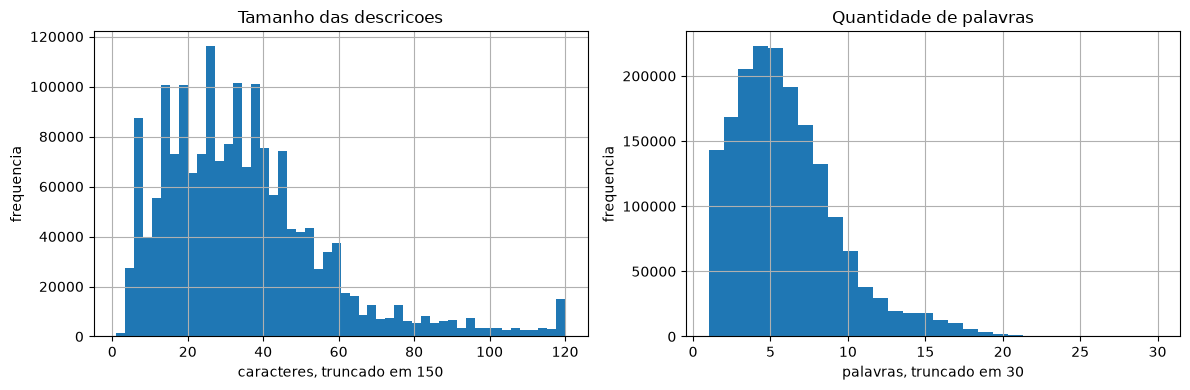

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
items["descricao_tamanho"].clip(upper=150).hist(bins=50, ax=axes[0])
axes[0].set_title("Tamanho das descricoes")
axes[0].set_xlabel("caracteres, truncado em 150")
axes[0].set_ylabel("frequencia")

items["descricao_palavras"].clip(upper=30).hist(bins=30, ax=axes[1])
axes[1].set_title("Quantidade de palavras")
axes[1].set_xlabel("palavras, truncado em 30")
axes[1].set_ylabel("frequencia")
plt.tight_layout()

In [15]:
exemplos_descricoes = pd.concat(
    [
        items.nsmallest(10, "descricao_tamanho")[[desc_col, "descricao_tamanho", "descricao_palavras", "ncm_str"]].assign(grupo="mais curtas"),
        items.nlargest(10, "descricao_tamanho")[[desc_col, "descricao_tamanho", "descricao_palavras", "ncm_str"]].assign(grupo="mais longas"),
    ],
    ignore_index=True,
)
exemplos_descricoes

,DESCRIÇÃO DO PRODUTO/SERVIÇO,descricao_tamanho,descricao_palavras,ncm_str,grupo
0,.,1,1,30061090,mais curtas
1,.,1,1,90183929,mais curtas
2,.,1,1,90189099,mais curtas
3,.,1,1,90189099,mais curtas
4,.,1,1,90189099,mais curtas
5,.,1,1,90189099,mais curtas
6,.,1,1,90189099,mais curtas
7,.,1,1,90189099,mais curtas
8,.,1,1,90189099,mais curtas
9,.,1,1,90189099,mais curtas


In [16]:
if UNIQUE_ITEMS_PATH.exists():
    produtos_unicos = pd.read_csv(UNIQUE_ITEMS_PATH)
    display(produtos_unicos.shape)
    display(produtos_unicos.head(20))
else:
    produtos_unicos = None
    print(f"Arquivo nao encontrado: {UNIQUE_ITEMS_PATH}")

(466284, 1)

,nome_produto
0,0 05m ultra microfiltro lc 109
1,0 1mg ml 1ml sandostatin inj novartis
2,0 2 ml 8 tube pcr strips without caps low profile clear pkg of 120 thin wall polypropylene instrucao de transporte te
3,0 221 504470 bosch bobina citroen bmw mi
4,0 25kg de massa epoxi
5,0 414 171 073 bomba injetora
6,0 5 mg ml 1ml sandostatin novartis
7,0 50 cm mangueira 3 8 2 tramas
8,0 70mm arame inox mole 304
9,0 8 affirmagen 2


## 3. NCM

**Por que importa para o TCC:** permite investigar quanto conhecimento estruturado ja existe na base e se ele pode apoiar a construcao ou validacao de categorias.

In [17]:
ncm_resumo = pd.DataFrame(
    {
        "metrica": [
            "itens",
            "NCM preenchido",
            "NCM ausente",
            "NCMs unicos",
            "NCMs unicos com descricao de tipo",
        ],
        "valor": [
            len(items),
            int(items["ncm_str"].notna().sum()),
            int(items["ncm_str"].isna().sum()),
            int(items["ncm_str"].nunique()),
            int(items[ncm_tipo_col].nunique()) if ncm_tipo_col else np.nan,
        ],
    }
)
ncm_resumo

,metrica,valor
0,itens,1765015
1,NCM preenchido,1765015
2,NCM ausente,0
3,NCMs unicos,6708
4,NCMs unicos com descricao de tipo,6187


In [18]:
ncm_cols = ["ncm_str"] + ([ncm_tipo_col] if ncm_tipo_col else [])
ncm_frequentes = (
    items.groupby(ncm_cols, dropna=False)
    .agg(
        itens=(desc_col, "size"),
        descricoes_unicas=("descricao_limpa_minima", "nunique"),
        tamanho_medio_descricao=("descricao_tamanho", "mean"),
    )
    .reset_index()
    .sort_values("itens", ascending=False)
)
ncm_frequentes.head(30)

,ncm_str,NCM/SH (TIPO DE PRODUTO),itens,descricoes_unicas,tamanho_medio_descricao
3242,49019900,"Outros livros, brochuras e impressos semelhantes",158207,26850,46.428571
6269,90189099,"Outros instrumentos e aparelhos para medicina, cirurgia, etc",95769,15720,40.650346
6279,90211020,Artigos e aparelhos para fraturas,53663,15648,47.843207
6286,90213190,Outras próteses articulares,23818,3929,47.48774
2572,38221990,NaN,21662,8597,47.410165
6241,90183929,"Outras sondas, catéteres e cânulas",20036,5135,50.634857
414,07099990,"Outros produtos hortícolas, frescos ou refrigerados",18867,1092,13.887528
3257,49119900,Outros impressos,16952,476,58.640573
6044,87089990,Outras partes e acessórios para tratores e veículos automóveis,16117,8960,24.409505
5021,84439933,Cartuchos de revelador (toners),15032,2275,41.846594


In [19]:
top_ncms_para_exemplos = ncm_frequentes.head(20)["ncm_str"].dropna().tolist()
ncm_descricoes = (
    items_for_examples[items_for_examples["ncm_str"].isin(top_ncms_para_exemplos)]
    .groupby("ncm_str", dropna=False)
    .agg(
        itens=(desc_col, "size"),
        descricoes_unicas=("descricao_limpa_minima", "nunique"),
        exemplos=(desc_col, lambda s: " | ".join(s.dropna().astype(str).drop_duplicates().head(5))),
    )
    .reset_index()
    .sort_values(["descricoes_unicas", "itens"], ascending=False)
)
ncm_descricoes

,ncm_str,itens,descricoes_unicas,exemplos
8,49019900,17734,6180,"BUR MAIS H2 0037P23040002LE | EDUCACAO DE JOVENS E ADULTOS: TEORIA, PRATICA E PROPOSTA | 2028 - A CONQUISTA ARTE 1 A..."
15,90189099,10774,5121,COLUMBUS - PROVA FEMORAL ESQUERDO F1L | 2107-1014 #CABO DIRECIONADOR RETO | 2210-32I #PROVAS DE INSERTES AZULTRIDENT...
16,90211020,6060,3821,PARAFUSO CORTICAL 3.5X26 MM | REF. 25-367-04-09 Placa 2.0mm Em L P/ Esq 4f Seg Lot:33417125-30/12/2049 Anv:800813503...
7,38221990,2460,1980,ELECSYS PROCELL- 11662988122 -ROCHE/// | ANTI-TG ELECSYS COBAS E 100 V5 - LOTE : 81019702 - Validade : 30/09/2025 | ...
13,87089990,1810,1464,"DISCO DE FREIO | KIT ARRIBITES | 32826023S BRACO PITMAN DIRECAO SISTEMA ZF | BUCHA SAPATA DT | BRONZE DE MANCAL 0,25"
18,90213190,2711,1386,PARAFUSO ROCKSCREW TCP 7 L30 | LINER PLASMAFIT POLIETILENO 36MM H 54 SIMETRICO - VITELENE | 5515F702 #MODELO TRIATHL...
14,90183929,2156,1279,"CATETER PERIFERICO, MATERIAL CATETER POLIMERO RADIOPACO, APLICACAO VENOSO, MATERIAL AGULHA AGULHA ACO INOX, DIAMETRO..."
0,-0000001,1610,977,BANANA BRANCA | ALFACE | CLORETO DE SÓDIO | BOBINAS | MILHO VERDE ESPIGA
6,27101932,1417,966,OLEO 5W30 BRUTUS SINTETICO DIESEL C2/C3 | CORREIA ALTERNADOR | MC 5W30 LTR | LUBRIFICANTE | OLEO 5W30 100% SINT. API...
4,21069090,1473,845,DESJEJUM ESTUDANTE DE GRADUAC.PRES.(IVS)III E IV | LIMAO TAHITI | MERENDA DIETA PASTOSA | JANTAR | JANTAR ALUNO UFCA...


## 4. Relacao descricao x NCM

**Por que importa para o TCC:** uma mesma descricao podendo apontar para varios NCMs, ou um NCM contendo muitas descricoes distintas, ajuda a validar a dificuldade do problema e a necessidade de tratamento textual.

Para manter o notebook reexecutavel, esta secao usa uma amostra fixa de ate 75 mil itens. As secoes anteriores ja trazem contagens globais de linhas, descricoes e NCMs.

In [20]:
descricao_para_ncm = (
    items_for_relation.groupby("descricao_limpa_minima")
    .agg(
        ocorrencias=(desc_col, "size"),
        ncms_unicos=("ncm_str", "nunique"),
        exemplo_original=(desc_col, "first"),
    )
    .reset_index()
    .sort_values(["ncms_unicos", "ocorrencias"], ascending=False)
)
top_descricoes_ncm = descricao_para_ncm.head(30).merge(
    items_for_relation.groupby("descricao_limpa_minima")["ncm_str"]
    .apply(lambda s: ", ".join(s.dropna().drop_duplicates().head(10)))
    .rename("exemplos_ncm")
    .reset_index(),
    on="descricao_limpa_minima",
    how="left",
)
top_descricoes_ncm

,descricao_limpa_minima,ocorrencias,ncms_unicos,exemplo_original,exemplos_ncm
0,coentro,110,23,COENTRO,"07032090, 07099990, 07129090, 12122100, 07049000, 01012900, 06042000, 07039090, 08039000, 21039099"
1,cebolinha,122,20,Cebolinha,"07031019, 07122000, 07039090, 07099990, 07089000, 07108000, 07069000, 07129090, 08071100, 01012900"
2,salsa,55,19,Salsa,"09092100, 07129090, 07039090, 07099990, 07049000, 07061000, -0000001, 07108000, 09011110, 07069000"
3,melancia,203,16,Melancia,"08071100, 07069000, 08140000, 01012900, 08071900, 04090000, 04079000, -0000001, 99999999, 08094000"
4,batata doce,163,15,Batata Doce,"07142000, 07101000, 07141000, 07019000, 07108000, 01012900, 07020000, 09011110, 12122100, -0000001"
5,quiabo,71,15,QUIABO,"07099990, 07061000, -0000001, 08109012, 01022110, 07019000, 20060000, 07108000, 07089000, 07095900"
6,goiaba,68,15,GOIABA,"08045010, 08041010, 07141000, 01022110, 04069020, 08013200, 07051900, 21069090, 07020000, 08109090"
7,cheiro verde,66,15,CHEIRO VERDE,"09109900, 07123900, 07099990, -0000001, 21039029, 07049000, 07099300, 07129020, 07051900, 08011900"
8,filtro de ar,60,15,FILTRO DE AR,"87089483, 87088000, 84213100, 87089990, 84219999, 84212300, 27101932, 84818099, 90184999, 84213990"
9,cenoura,223,14,CENOURA,"07061000, 08134090, 07011000, 01022110, 07031019, 20060000, 07069000, 07049000, 01012900, 07101000"


In [21]:
descricoes_com_varios_ncms = descricao_para_ncm[descricao_para_ncm["ncms_unicos"] > 1]
pd.DataFrame(
    {
        "metrica": [
            "descricoes com mais de um NCM na amostra",
            "percentual das descricoes unicas na amostra",
            "ocorrencias afetadas na amostra",
            "percentual dos itens da amostra",
        ],
        "valor": [
            len(descricoes_com_varios_ncms),
            f"{len(descricoes_com_varios_ncms) / len(descricao_para_ncm):.2%}",
            int(descricoes_com_varios_ncms["ocorrencias"].sum()),
            f"{descricoes_com_varios_ncms['ocorrencias'].sum() / len(items_for_relation):.2%}",
        ],
    }
)

,metrica,valor
0,descricoes com mais de um NCM na amostra,1162
1,percentual das descricoes unicas na amostra,2.55%
2,ocorrencias afetadas na amostra,11372
3,percentual dos itens da amostra,15.16%


In [22]:
if not descricoes_com_varios_ncms.empty:
    exemplo_desc = descricoes_com_varios_ncms.iloc[0]["exemplo_original"]
    display(items_for_relation[items_for_relation[desc_col].astype("string").str.strip().str.lower() == str(exemplo_desc).strip().lower()][
        [col for col in [desc_col, "ncm_str", ncm_tipo_col, emitente_col, uf_col, municipio_col] if col]
    ].drop_duplicates().head(30))
else:
    print("Nao foram encontradas descricoes associadas a mais de um NCM.")

,DESCRIÇÃO DO PRODUTO/SERVIÇO,ncm_str,NCM/SH (TIPO DE PRODUTO),RAZÃO SOCIAL EMITENTE,UF EMITENTE,MUNICÍPIO EMITENTE
1837853,COENTRO,07032090,"Alhos, frescos ou refrigerados, exceto para semeadura",COOPERATIVA AGRO INDUSTRIAL DE GUARATINGA,BA,GUARATINGA
240486,COENTRO,07099990,"Outros produtos hortícolas, frescos ou refrigerados",RAIMUNDO FERREIRA DE MENESES,MA,VARGEM GRANDE
2027355,COENTRO,07099990,"Outros produtos hortícolas, frescos ou refrigerados",OSVALDO CAMIRANGA GUAJAJARA,MA,BOM JARDIM
1503187,COENTRO,07099990,"Outros produtos hortícolas, frescos ou refrigerados",ADW COMERCIO DE ALIMENTOS LTDA,RN,NATAL
217969,COENTRO,07099990,"Outros produtos hortícolas, frescos ou refrigerados",RILDO COELHO RODRIGUES LTDA,GO,ANAPOLIS
230129,COENTRO,07099990,"Outros produtos hortícolas, frescos ou refrigerados",COOPERATIVA DOS PROD. AGROP. DE GARANHUNS - COOPAGA,PE,GARANHUNS
2081386,COENTRO,07099990,"Outros produtos hortícolas, frescos ou refrigerados",COOPERATIVA MISTA DOS PRODUTORES RURAIS NA AGRICUL,PB,SANTA RITA
1323938,COENTRO,07129090,"Outros produtos hortícolas; misturas de produtos hortícolas, secos, inclusive pedaços, fatias, etc",N S APARECIDA DISTRIBUIDORA DE ALIMENTOS E TRANSPORTE LTDA,RJ,DUQUE DE CAXIAS
875431,COENTRO,07099990,"Outros produtos hortícolas, frescos ou refrigerados",REFISERVI REFEICOES INDUSTRIAIS LTDA,RJ,RIO DE JANEIRO
332645,Coentro,07129090,"Outros produtos hortícolas; misturas de produtos hortícolas, secos, inclusive pedaços, fatias, etc",VALDETE OLIVEIRA SANTOS,BA,PRADO


In [23]:
top_ncms_heterogeneos = (
    items.groupby("ncm_str", dropna=False)
    .agg(ocorrencias=(desc_col, "size"), descricoes_unicas=("descricao_limpa_minima", "nunique"))
    .reset_index()
    .sort_values(["descricoes_unicas", "ocorrencias"], ascending=False)
    .head(30)
)
exemplos_por_ncm = (
    items_for_examples[items_for_examples["ncm_str"].isin(top_ncms_heterogeneos["ncm_str"].dropna())]
    .groupby("ncm_str", dropna=False)[desc_col]
    .apply(lambda s: " | ".join(s.dropna().astype(str).drop_duplicates().head(8)))
    .rename("exemplos_descricao")
    .reset_index()
)
ncm_para_descricao = top_ncms_heterogeneos.merge(exemplos_por_ncm, on="ncm_str", how="left")
ncm_para_descricao

,ncm_str,ocorrencias,descricoes_unicas,exemplos_descricao
0,49019900,158207,26850,"BUR MAIS H2 0037P23040002LE | EDUCACAO DE JOVENS E ADULTOS: TEORIA, PRATICA E PROPOSTA | 2028 - A CONQUISTA ARTE 1 A..."
1,90189099,95769,15720,COLUMBUS - PROVA FEMORAL ESQUERDO F1L | 2107-1014 #CABO DIRECIONADOR RETO | 2210-32I #PROVAS DE INSERTES AZULTRIDENT...
2,90211020,53663,15648,PARAFUSO CORTICAL 3.5X26 MM | REF. 25-367-04-09 Placa 2.0mm Em L P/ Esq 4f Seg Lot:33417125-30/12/2049 Anv:800813503...
3,87089990,16117,8960,"DISCO DE FREIO | KIT ARRIBITES | 32826023S BRACO PITMAN DIRECAO SISTEMA ZF | BUCHA SAPATA DT | BRONZE DE MANCAL 0,25..."
4,38221990,21662,8597,ELECSYS PROCELL- 11662988122 -ROCHE/// | ANTI-TG ELECSYS COBAS E 100 V5 - LOTE : 81019702 - Validade : 30/09/2025 | ...
5,39174090,9440,6344,"CURVA 90 ESGOTO 100MM | TE SOLDAVEL 40MM 457 KRONA | TUBO EXTENS BCO 1,5M BLUKIT-5,300x31,400 | ADAPTADOR PVC SOLD. ..."
6,27101932,13136,5369,OLEO 5W30 BRUTUS SINTETICO DIESEL C2/C3 | CORREIA ALTERNADOR | MC 5W30 LTR | LUBRIFICANTE | OLEO 5W30 100% SINT. API...
7,90183929,20036,5135,"CATETER PERIFERICO, MATERIAL CATETER POLIMERO RADIOPACO, APLICACAO VENOSO, MATERIAL AGULHA AGULHA ACO INOX, DIAMETRO..."
8,-0000001,13731,4489,"BANANA BRANCA | ALFACE | CLORETO DE SÓDIO | BOBINAS | MILHO VERDE ESPIGA | ALHO | ABOBRINHA | SALGADOS COXINHA, SABO..."
9,84219999,11024,4211,REFIL CARBON BLOCK 9. 3/4 | ELEMENTO DO FILTRO R90-10- REF: 6013.006.035.00.7 | ELEMENTO FILT | FILTRO COMBUSTIVEL |...


## 5. Contexto da compra

**Por que importa para o TCC:** emitentes, localidades, unidades, quantidades e valores ajudam a compreender de onde vem a heterogeneidade textual da base.

In [24]:
contexto_resumo = pd.DataFrame(
    {
        "campo": ["emitentes", "UFs", "municipios", "unidades"],
        "unicos": [
            items[emitente_col].nunique() if emitente_col else np.nan,
            items[uf_col].nunique() if uf_col else np.nan,
            items[municipio_col].nunique() if municipio_col else np.nan,
            items[unidade_col].nunique() if unidade_col else np.nan,
        ],
        "preenchimento_pct": [
            round(100 * items[emitente_col].notna().mean(), 2) if emitente_col else np.nan,
            round(100 * items[uf_col].notna().mean(), 2) if uf_col else np.nan,
            round(100 * items[municipio_col].notna().mean(), 2) if municipio_col else np.nan,
            round(100 * items[unidade_col].notna().mean(), 2) if unidade_col else np.nan,
        ],
    }
)
contexto_resumo

,campo,unicos,preenchimento_pct
0,emitentes,45154,100.0
1,UFs,27,100.0
2,municipios,3319,100.0
3,unidades,1377,99.9


In [27]:
def top_counts(column, n=20):
    """Return top frequencies for a categorical column."""
    return (
        items[column]
        .astype("string")
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="itens")
        .assign(percentual=lambda d: pct(d["itens"] / len(items)))
        .head(n)
    )

if emitente_col:
    display(top_counts(emitente_col, 20))
if uf_col:
    display(top_counts(uf_col, 20))
if municipio_col:
    display(top_counts(municipio_col, 20))
if unidade_col:
    display(top_counts(unidade_col, 30))

,RAZÃO SOCIAL EMITENTE,itens,percentual
0,EMPRES BRASILEIRA DE CORREIOS E TELEGRAFOS,77760,4.41
1,BRS SUPRIMENTOS CORPORATIVOS S/A,77530,4.39
2,ENDOLOG LOGISTICA E ARMAZENS LTDA,51289,2.91
3,AUTOPEL AUTOMACAO COMERCIAL E INFORMATICA LTDA.,31347,1.78
4,TRAUMINAS DIST MAT CIRURG HOSP LTDA,23947,1.36
5,BIO 2 IMP. E COM DE MAT. MED. HOSP. LTDA,17063,0.97
6,CASA DA MOEDA DO BRASIL,16091,0.91
7,EDITORA FTD S.A.,12837,0.73
8,SIMPRESS COMERCIO LOCACAO E SERVICOS LTDA,12174,0.69
9,EDITORA MODERNA LTDA.,11697,0.66


,UF EMITENTE,itens,percentual
0,SP,408267,23.13
1,RJ,262817,14.89
2,RS,223090,12.64
3,MG,126324,7.16
4,PR,102814,5.83
5,DF,84057,4.76
6,SC,58220,3.3
7,PE,55241,3.13
8,PA,49984,2.83
9,BA,45477,2.58


,MUNICÍPIO EMITENTE,itens,percentual
0,RIO DE JANEIRO,194747,11.03
1,SAO PAULO,117319,6.65
2,CAJAMAR,85029,4.82
3,BRASILIA,78396,4.44
4,PORTO ALEGRE,76427,4.33
5,SAO LEOPOLDO,60058,3.4
6,BELO HORIZONTE,47254,2.68
7,CURITIBA,45016,2.55
8,MANAUS,33594,1.9
9,SANTANA DE PARNAIBA,32282,1.83


,UNIDADE,itens,percentual
0,UNIDAD,1027289,58.2
1,KG,304649,17.26
2,PEÇA,118591,6.72
3,L,25403,1.44
4,CX,25396,1.44
5,LITRO,19951,1.13
6,PCT,16899,0.96
7,MI,16124,0.91
8,FR,10244,0.58
9,PAC,10142,0.57


In [28]:
numeric_cols = [col for col in ["quantidade_num", "valor_unitario_num", "valor_total_num", "valor_nota_num"] if col in items.columns]
items[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,quantidade_num,valor_unitario_num,valor_total_num,valor_nota_num
count,1765015.0,1765015.0,1765015.0,0.0
mean,851.59389,4109.794621,15328.547349,<NA>
std,35387.386016,101800.930737,521226.19864,<NA>
min,0.0,0.0,0.0,<NA>
1%,0.2,0.31,1.1,<NA>
5%,1.0,1.23,8.1,<NA>
25%,1.0,6.35,72.45,<NA>
50%,5.0,22.07,259.8,<NA>
75%,30.0,190.0,1100.0,<NA>
95%,420.0,3472.26,11681.63,<NA>


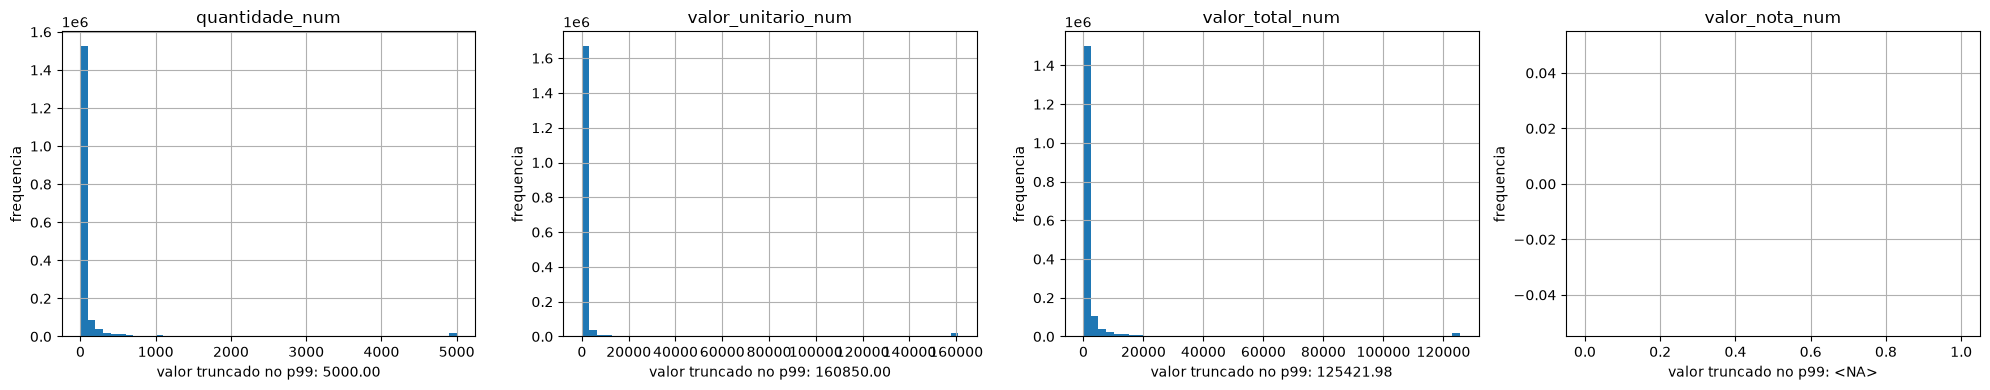

In [29]:
if numeric_cols:
    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
    if len(numeric_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_cols):
        upper = items[col].quantile(0.99)
        items[col].clip(upper=upper).hist(bins=50, ax=ax)
        ax.set_title(col)
        ax.set_xlabel(f"valor truncado no p99: {upper:.2f}")
        ax.set_ylabel("frequencia")
    plt.tight_layout()
else:
    print("Nenhuma coluna numerica de contexto foi detectada.")

In [30]:
agrupadores_contexto = [col for col in [uf_col, municipio_col, emitente_col, unidade_col] if col]
for col in agrupadores_contexto:
    resumo = (
        items.groupby(col, dropna=False)
        .agg(
            itens=(desc_col, "size"),
            descricoes_unicas=("descricao_limpa_minima", "nunique"),
            ncms_unicos=("ncm_str", "nunique"),
            tamanho_medio_descricao=("descricao_tamanho", "mean"),
        )
        .assign(descricoes_por_100_itens=lambda d: 100 * d["descricoes_unicas"] / d["itens"])
        .sort_values("itens", ascending=False)
        .head(20)
    )
    print(f"\nResumo por {col}")
    display(resumo)


Resumo por UF EMITENTE


,itens,descricoes_unicas,ncms_unicos,tamanho_medio_descricao,descricoes_por_100_itens
UF EMITENTE,,,,,
SP,408267,105527,4069,42.712867,25.847546
RJ,262817,74226,3668,35.61754,28.242465
RS,223090,42414,2853,37.867314,19.012058
MG,126324,49868,3171,34.365829,39.476267
PR,102814,35054,2723,33.95523,34.094579
DF,84057,24864,2345,31.394685,29.579928
SC,58220,23328,2361,32.2,40.068705
PE,55241,15194,1850,29.127188,27.504933
PA,49984,16305,2064,27.212948,32.620439



Resumo por MUNICÍPIO EMITENTE


,itens,descricoes_unicas,ncms_unicos,tamanho_medio_descricao,descricoes_por_100_itens
MUNICÍPIO EMITENTE,,,,,
RIO DE JANEIRO,194747,52317,2963,37.025772,26.864085
SAO PAULO,117319,47014,2450,50.30556,40.073645
CAJAMAR,85029,4056,603,43.393936,4.770137
BRASILIA,78396,23306,2280,31.817083,29.728558
PORTO ALEGRE,76427,11647,1334,44.656862,15.239379
SAO LEOPOLDO,60058,2102,432,43.094708,3.499950
BELO HORIZONTE,47254,17598,1623,37.212765,37.241292
CURITIBA,45016,14990,1492,37.318331,33.299271
MANAUS,33594,11075,1648,30.955081,32.967197



Resumo por RAZÃO SOCIAL EMITENTE


,itens,descricoes_unicas,ncms_unicos,tamanho_medio_descricao,descricoes_por_100_itens
RAZÃO SOCIAL EMITENTE,,,,,
EMPRES BRASILEIRA DE CORREIOS E TELEGRAFOS,77760,1860,2,43.990098,2.391975
BRS SUPRIMENTOS CORPORATIVOS S/A,77530,2720,436,43.193551,3.508319
ENDOLOG LOGISTICA E ARMAZENS LTDA,51289,2648,40,45.396284,5.162900
AUTOPEL AUTOMACAO COMERCIAL E INFORMATICA LTDA.,31347,1223,234,37.850033,3.901490
TRAUMINAS DIST MAT CIRURG HOSP LTDA,23947,4257,9,34.011567,17.776757
BIO 2 IMP. E COM DE MAT. MED. HOSP. LTDA,17063,7836,18,80.889703,45.923929
CASA DA MOEDA DO BRASIL,16091,41,13,58.119881,0.254801
EDITORA FTD S.A.,12837,387,1,81.90208,3.014723
SIMPRESS COMERCIO LOCACAO E SERVICOS LTDA,12174,352,44,40.484886,2.891408



Resumo por UNIDADE


,itens,descricoes_unicas,ncms_unicos,tamanho_medio_descricao,descricoes_por_100_itens
UNIDADE,,,,,
UNIDAD,1027289,317135,5715,39.666008,30.871060
KG,304649,24350,1832,17.645638,7.992805
PEÇA,118591,55639,2635,33.974998,46.916714
L,25403,1981,361,21.662914,7.798292
CX,25396,9674,984,42.15908,38.092613
LITRO,19951,4681,551,26.949326,23.462483
PCT,16899,5331,697,32.685011,31.546245
MI,16124,55,24,58.086517,0.341106
FR,10244,5787,715,49.148965,56.491605


## Fechamento

Pontos para levar para a escrita do TCC:

- tamanho e cobertura da base antes do preprocessamento;
- evidencia empirica de textos curtos e ruidosos;
- disponibilidade e concentracao dos NCMs;
- casos em que descricao e NCM nao formam uma relacao simples de um-para-um;
- heterogeneidade causada por emitentes, localidades, unidades e padroes de valor.